# MAB(Multi Armed Bandit) 그거 어떻게 쓰는건데…?

여러 옵션 중 **알아서 최적을 찾아주는** Multi-Armed Bandit 을 **Thompson Sampling**(베이지안·베타 분포)으로
직접 시뮬레이션해 봅니다. 배너마다 '진짜 클릭 확률'을 정해 두면, 알고리즘은 그 값을 모른 채
탐색(explore)과 수확(exploit)의 균형을 맞추며 최적 배너를 찾아갑니다.

실습 흐름:
- **실습 1.** 기본 Thompson Sampling — 베타 분포가 수렴하며 최적 배너에 노출이 집중되는 과정
- **실습 2.** AB 테스트 vs MAB — 고정 분할 AB와 누적 regret 비교 (AB의 실험 비용을 수치로)
- **실습 3.** Alpha × Coefficient — 비슷하고 낮은 CTR 배너의 분포를 계수로 분리
- **실습 4.** Discounted Thompson Sampling — 최적이 바뀌는(시즈널) 환경에 적응

> 이 챕터는 데이터 파일이 없습니다. 배너의 '진짜 확률'을 정해 두고 노트북이 직접 시뮬레이션을 돌리므로,
> 알고리즘이 그 확률을 찾아가는 과정을 그대로 관찰할 수 있습니다.

## 0. 준비

아래 첫 셀이 의존성을 설치합니다. 시뮬레이션은 `np.random.seed(42)` 로 재현됩니다.

In [1]:
# 의존성 설치 (이미 설치돼 있으면 빠르게 넘어갑니다)
# %pip 매직은 현재 커널 환경에 설치하므로 PATH 문제 없이 동작합니다.
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta

np.random.seed(42)   # 재현성

## 실습 1. 기본 Thompson Sampling

각 배너의 클릭(보상) 확률을 하나의 숫자가 아니라 **분포**로 봅니다. 보상 여부(0/1)는 **베타 분포 Beta(α, β)**
의 α(보상 받은 횟수+1), β(못 받은 횟수+1)에 바로 누적되며(conjugacy), 데이터가 쌓일수록 분산이 줄어
실제 확률 근처에 확률밀도가 모입니다. 매 시도마다 **각 배너의 분포에서 표본을 뽑아 가장 큰 배너를 노출하고**,
관측한 보상으로 그 배너의 분포를 갱신합니다 — 분포 표본을 쓰기 때문에 탐색과 수확이 자연스럽게 섞입니다.

In [3]:
NUM_TRIALS = 2000
BANNER_PROBABILITIES = [0.2, 0.5, 0.75]   # 배너의 '진짜' 클릭 확률 (알고리즘은 모름)


class Banner:
    def __init__(self, p):
        self.p = p      # 실제 보상 확률 (시뮬레이션 환경만 알고, 알고리즘은 모름)
        self.a = 1      # 베타 분포의 α (보상 받은 횟수 + 1)
        self.b = 1      # 베타 분포의 β (보상 못 받은 횟수 + 1)
        self.N = 0      # 이 배너가 선택된(노출된) 총 횟수

    def show(self):       # 배너를 노출해 클릭 여부 반환 (확률 p로 1, 아니면 0)
        return np.random.random() < self.p

    def sample(self):     # 현재 베타 분포에서 표본 하나 추출 (탐색·수확의 균형이 여기서 생김)
        return np.random.beta(self.a, self.b)

    def update(self, x):  # 관측한 보상(x)으로 분포 파라미터 갱신
        self.a += x
        self.b += 1 - x
        self.N += 1

배너 세 개를 만들어 2,000번 노출을 시뮬레이션하면서, 시점별로 각 배너의 베타 분포가 어떻게 좁아지는지 그려 봅니다.

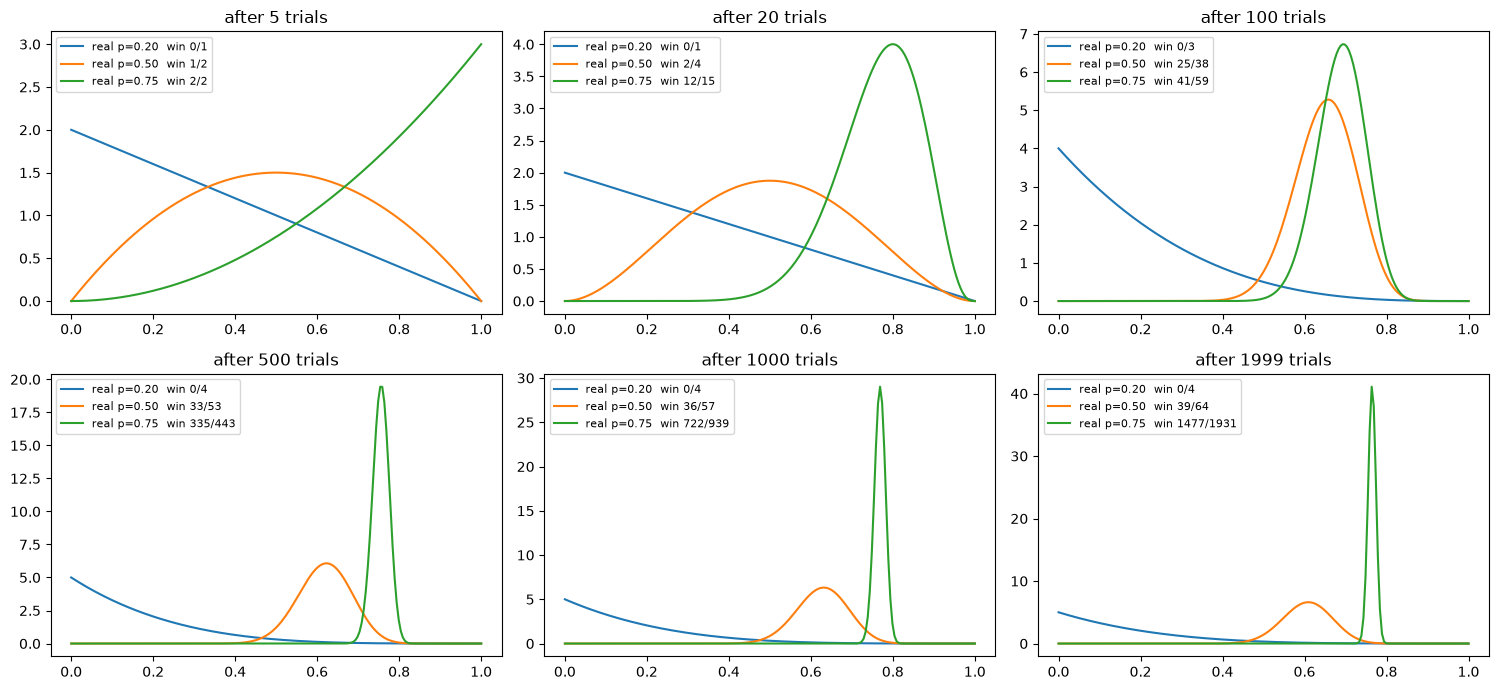

total reward earned: 1516.0
overall win rate   : 0.758
times each selected : [4, 64, 1932]


In [4]:
banners = [Banner(p) for p in BANNER_PROBABILITIES]
checkpoints = [5, 20, 100, 500, 1000, 1999]   # 분포를 들여다볼 시점
rewards = np.zeros(NUM_TRIALS)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
x = np.linspace(0, 1, 200)
for i in range(NUM_TRIALS):
    j = np.argmax([b.sample() for b in banners])   # Thompson sampling: 표본이 가장 큰 배너 선택
    if i in checkpoints:
        ax = axes.ravel()[checkpoints.index(i)]
        for b in banners:
            ax.plot(x, beta.pdf(x, b.a, b.b), label=f"real p={b.p:.2f}  win {int(b.a - 1)}/{int(b.N)}")
        ax.set_title(f"after {i} trials"); ax.legend(fontsize=8)
    x_reward = banners[j].show()
    rewards[i] = x_reward
    banners[j].update(x_reward)
plt.tight_layout(); plt.show()

print("total reward earned:", rewards.sum())
print("overall win rate   :", round(rewards.sum() / NUM_TRIALS, 3))
print("times each selected :", [int(b.N) for b in banners])

가장 확률이 높은 배너(0.75)가 노출을 거의 독식하고, 그 과정에서 다른 배너의 노출은 초반 탐색 수준으로
최소화됩니다. 전체 승률도 최적 배너의 확률에 가깝게 수렴합니다. (출력 수치는 시드에 따라 달라집니다.)

## 실습 2. AB 테스트 vs MAB

전통적인 AB 테스트는 트래픽을 고정 비율로 나눠 실험 기간 내내 유지합니다. 성과가 낮은 안에도 트래픽을
계속 흘려보내므로 그만큼 **실험 비용(기회손실)**이 쌓입니다. 원문의 구매전환 예시(대조군 5% / A안 7% /
B안 1%)로, 고정 1/3 분할 AB와 Thompson Sampling 의 **누적 regret**(최적 대비 손해)을 비교합니다.

In [5]:
PROBS = np.array([0.05, 0.07, 0.01])   # 대조군 / 실험군 A / 실험군 B
OPT = PROBS.max()                       # 최적(=A안 7%)
N = 2000


def run_ab(probs, n):
    # 고정 1/3 균등 분할: 매 노출마다 임의의 안을 동일 확률로 선택
    arms = np.random.randint(len(probs), size=n)
    reward = (np.random.random(n) < probs[arms]).sum()
    return arms, reward


def run_ts(sched, n, gamma=None, decay_every=50):
    # Thompson Sampling. sched(i) = i번째 노출 시점의 '진짜' 확률 (실습 4에서는 시간에 따라 바뀜)
    # gamma 를 주면 decay_every 노출마다 과거 근거를 감쇠한다 (실습 4의 Discounted TS)
    k = len(sched(0))
    a = np.ones(k); b = np.ones(k)
    arms = np.zeros(n, dtype=int); reward = np.zeros(n)
    for i in range(n):
        probs = sched(i)
        if gamma and i > 0 and i % decay_every == 0:
            a = 1 + gamma * (a - 1); b = 1 + gamma * (b - 1)   # 분산 ↑ → 재탐색
        j = int(np.argmax(np.random.beta(a, b)))
        x = int(np.random.random() < probs[j])
        a[j] += x; b[j] += 1 - x
        arms[i] = j; reward[i] = x
    return arms, reward

두 방식을 같은 시나리오로 2,000번 돌려, 최적안(A) 대비 놓친 기대 클릭의 누적(regret)을 비교합니다.

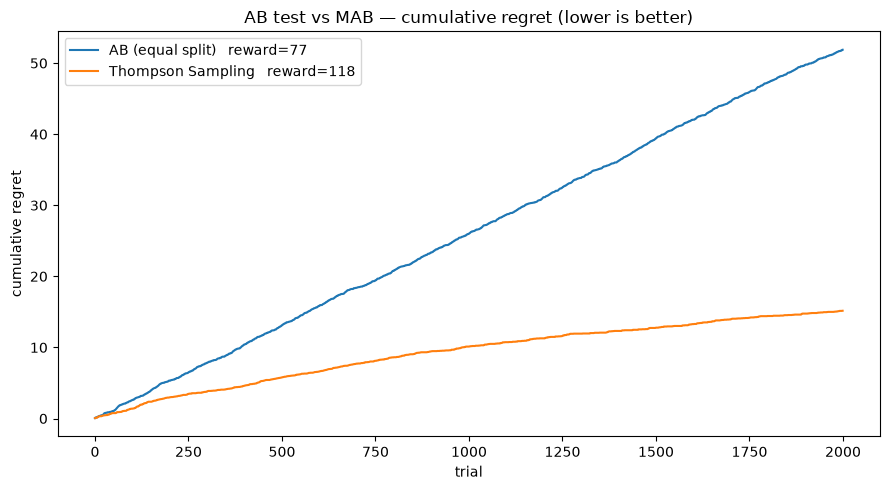

AB  total reward: 77
MAB total reward: 118


In [6]:
ab_arms, ab_reward = run_ab(PROBS, N)
ts_arms, ts_r = run_ts(lambda i: PROBS, N)
ab_regret = np.cumsum(OPT - PROBS[ab_arms])   # 최적안 대비 놓친 기대 클릭의 누적
ts_regret = np.cumsum(OPT - PROBS[ts_arms])
ts_reward = int(ts_r.sum())

plt.figure(figsize=(9, 5))
plt.plot(ab_regret, label=f"AB (equal split)   reward={ab_reward}")
plt.plot(ts_regret, label=f"Thompson Sampling   reward={ts_reward}")
plt.xlabel("trial"); plt.ylabel("cumulative regret")
plt.title("AB test vs MAB — cumulative regret (lower is better)")
plt.legend(); plt.tight_layout(); plt.show()

print(f"AB  total reward: {ab_reward}")
print(f"MAB total reward: {ts_reward}")

고정 분할 AB의 누적 regret은 거의 직선으로 늘어나는 반면(성과 낮은 B안에도 계속 트래픽을 쓰므로),
Thompson Sampling 은 빠르게 최적 안으로 트래픽을 몰아 regret 증가가 완만해집니다. 누적 보상도 MAB가
더 큽니다. AB 테스트가 짧은 탐색 후 '평생 수확'이라면, MAB는 탐색과 수확을 계속 저울질합니다.

## 실습 3. Alpha × Coefficient

클릭율이 **낮고**(예: 0.3~1%) 배너 간 차이도 **작은**(예: 0.9% vs 0.6% vs 0.3%) 영역에서는, 클릭(보상)이
드물어 **α가 β보다 훨씬 작게** 유지됩니다. 그래서 베타 분포들이 모두 0 근처에 몰려 거의 겹치고, 표본의
변별력이 떨어져 더 좋은 배너가 노출을 충분히 가져가지 못합니다. 바로 이 상황에서 계수가 효과적입니다 —
보상 시 **α에 계수를 곱해**(예: +1 대신 +15) 더해 주면 드문 클릭 신호가 증폭되어 분포 평균이 멀리
벌어지고 표본이 또렷이 갈립니다. (반대로 CTR이 높아 α가 β와 비슷한 규모면 분포가 이미 잘 갈려 계수의
효용은 작습니다.)

단, 이는 평균을 의도적으로 부풀리는 분리 휴리스틱으로 추정값이 실제 CTR은 아니며, 매 노출마다 온라인으로
곱하면 초반 운에 고착될 수 있어 어느 정도 모은 배치 집계 위에 적용하는 편이 안전합니다.

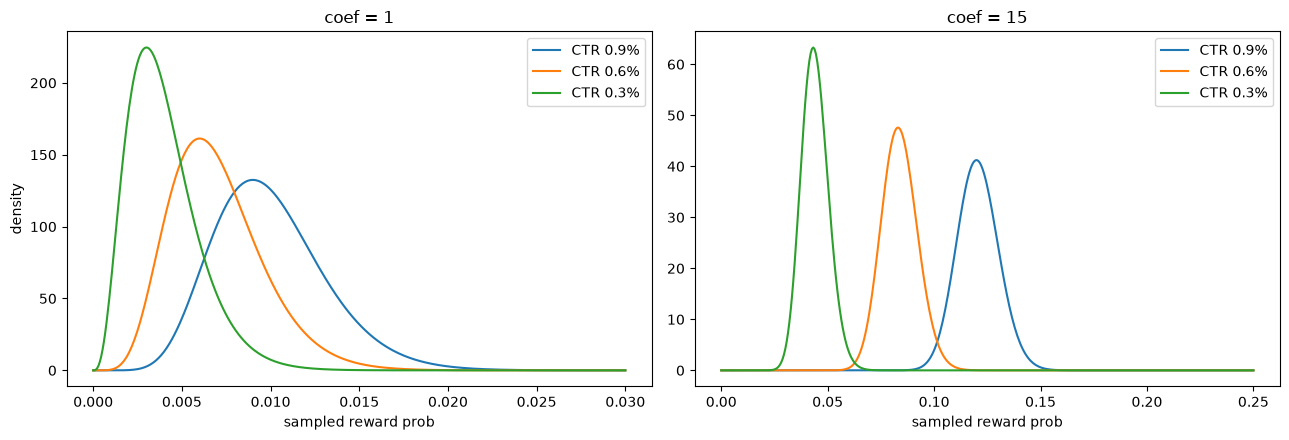

실제 CTR(%)        : [0.9, 0.6, 0.3]
plain(coef=1) 노출% : [75.4, 21.7, 3.0]
coef=15       노출% : [99.8, 0.2, 0.0]


In [7]:
CTR = np.array([0.009, 0.006, 0.003])   # 낮고 서로 가까운 클릭율 (0.9% / 0.6% / 0.3%)
IMPR = 1000                              # 각 배너를 균등 노출했다고 가정한 노출 수
wins = (CTR * IMPR).round().astype(int)     # 균등 노출 시 기대 클릭 수: [9, 6, 3] → 알파 << 베타
losses = IMPR - wins

def make_beta(coef):
    return 1 + coef * wins, 1 + losses    # 보상(클릭) 시 알파에 계수를 곱해 더함

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, coef, xmax in zip(axes, [1, 15], [0.03, 0.25]):
    a, b = make_beta(coef)
    xx = np.linspace(0, xmax, 400)
    for k, p in enumerate(CTR):
        ax.plot(xx, beta.pdf(xx, a[k], b[k]), label=f"CTR {p:.1%}")
    ax.set_title(f"coef = {coef}"); ax.set_xlabel("sampled reward prob"); ax.legend()
axes[0].set_ylabel("density")
plt.tight_layout(); plt.show()

# 각 분포에서 표본을 많이 뽑아, 최대값(=노출 선택)이 되는 비율
def exposure_share(coef, draws=20000):
    a, b = make_beta(coef)
    s = np.random.beta(a[:, None], b[:, None], size=(len(CTR), draws))
    return np.bincount(s.argmax(axis=0), minlength=len(CTR)) / draws

print("실제 CTR(%)        :", (CTR * 100).round(1).tolist())
print("plain(coef=1) 노출% :", (exposure_share(1) * 100).round(1).tolist())
print("coef=15       노출% :", (exposure_share(15) * 100).round(1).tolist())

일반 TS에서는 세 분포가 0 근처에 겹쳐 노출이 고르게 흩어지지만, 계수를 곱한 쪽은 평균이 벌어지며
가장 높은 CTR(0.9%) 배너에 노출이 또렷이 집중됩니다.

## 실습 4. Discounted Thompson Sampling

시즈널리티처럼 **최적 옵션이 시간에 따라 바뀌는** 환경에서는, 데이터를 그냥 누적하면 과거에 좋았던
배너가 관성으로 계속 상위에 남습니다. 최신 데이터에 더 큰 가중치를 주기 위해 주기적으로 α·β의
'누적 근거'를 1 미만 계수로 감쇠시키면(분산이 늘어 다시 탐색 기회가 생김), 변화에 빠르게 적응합니다.
아래는 1000번째 시도에서 최적 배너가 뒤바뀌는 환경입니다.

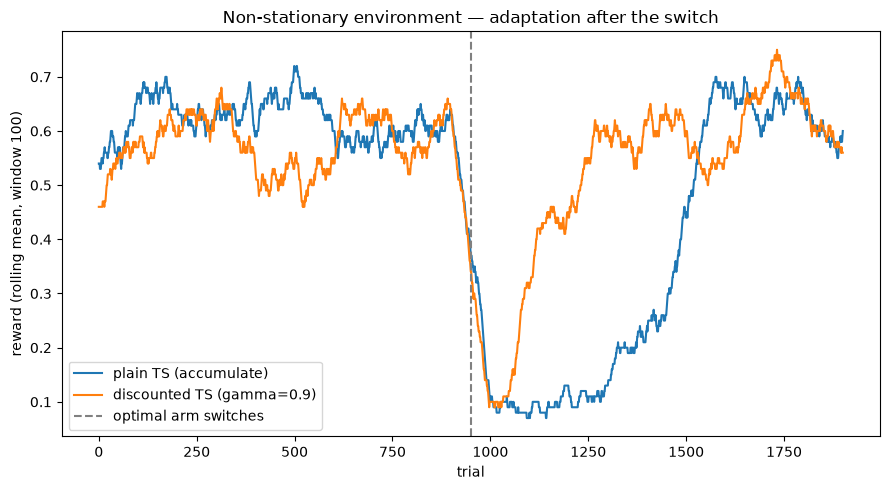

phase 2 reward — plain: 367, discounted: 510


In [8]:
SCHED = lambda i: np.array([0.6, 0.3, 0.1]) if i < 1000 else np.array([0.1, 0.3, 0.6])
N4 = 2000

_, r_plain = run_ts(SCHED, N4)               # 데이터를 그냥 누적
_, r_disc = run_ts(SCHED, N4, gamma=0.9)     # 50번 노출마다 α, β 에 0.9 를 곱해 과거 근거를 감쇠

w = 100
roll = lambda r: np.convolve(r, np.ones(w) / w, mode="valid")
plt.figure(figsize=(9, 5))
plt.plot(roll(r_plain), label="plain TS (accumulate)")
plt.plot(roll(r_disc), label="discounted TS (gamma=0.9)")
plt.axvline(1000 - w // 2, color="gray", ls="--", label="optimal arm switches")
plt.xlabel("trial"); plt.ylabel(f"reward (rolling mean, window {w})")
plt.title("Non-stationary environment — adaptation after the switch")
plt.legend(); plt.tight_layout(); plt.show()

print(f"phase 2 reward — plain: {r_plain[1000:].sum():.0f}, discounted: {r_disc[1000:].sum():.0f}")

전환 이전에는 둘이 비슷하지만, 최적 배너가 바뀐 뒤에는 할인 TS가 빠르게 새 최적으로 갈아타 후반
구간 보상이 더 높습니다. 누적만 하는 일반 TS는 과거에 좋았던 배너를 한동안 놓지 못합니다.

## 마무리 — 알고리즘 밖의 현실, 그리고 적절한 기회

알고리즘 요소는 아니지만 현실적인 고민도 있습니다. 예를 들어 직광고처럼 클릭율과 무관하게 일정 노출을
보장해야 하는 배너가 있다면, 설계 단계에서 **노출 순위를 강제할 수 있는 구조**(해당 배너는 샘플링을
건너뛰고 고정 노출, 나머지에만 샘플 순위 적용)를 마련해 두는 편이 현명합니다.

데이터 성숙도가 낮은 조직이라면 단번에 복잡한 알고리즘을 도입하기 어려울 수 있습니다. 더 중요한 일이
많을 수도, 조직 안에서 신뢰를 더 쌓아야 할 수도 있죠. 그래도 틈틈이 기회를 노린다면 적절한 때는 옵니다.